In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
from contra_seq_dataset import get_dataset_array, get_anc_map
import copy

test_or_train = 'train'

home = '/home/kat/Repos/SALSA/'
anc_path = f'{home}data/model_ready/01/{test_or_train}/anchor_smiles.csv'
aug_path = f'{home}data/model_ready/01/{test_or_train}/augmented_smiles.csv'

ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
df = copy.deepcopy(ds_arr)
df_sort = df.sort_values(by='smiles', key=lambda x: x.str.len())
# display(df_sort)

In [5]:
df_ancs = df_sort[df_sort.atype=='Anc'][:70]
# df_ancs

10430 Cc1ccccc1CCN


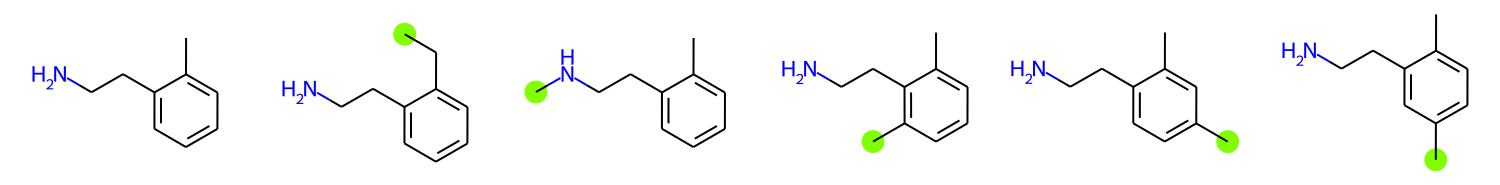

2775 C=CCCCCCCCCO


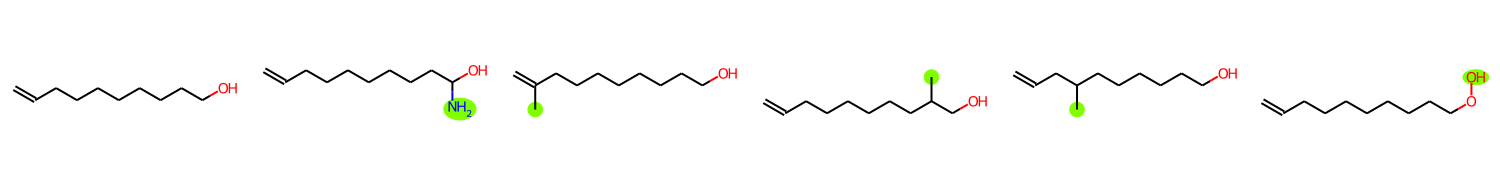

17529 CSCCCCCN=C=S


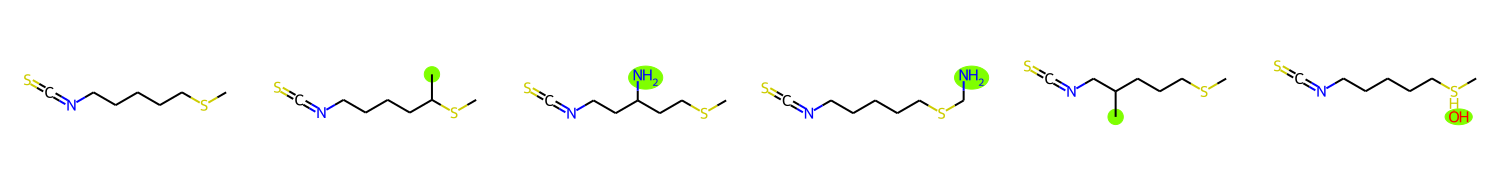

6105 C=CCCCCCCC=C


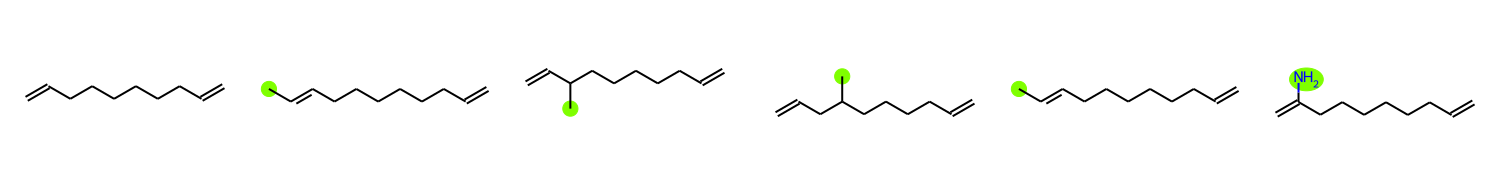

9555 CCCCCOCC(O)CO


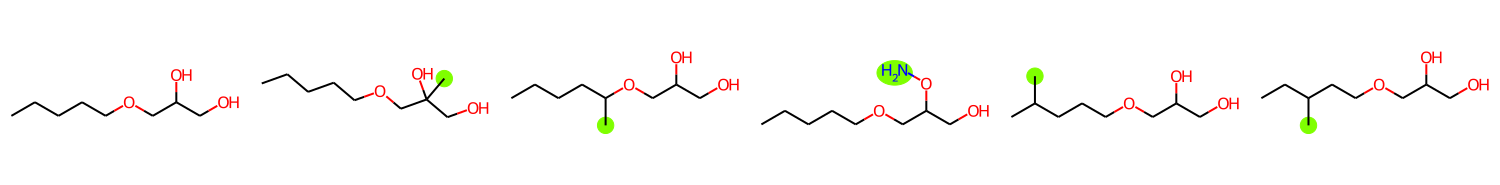

11650 O=CCCc1ccccc1


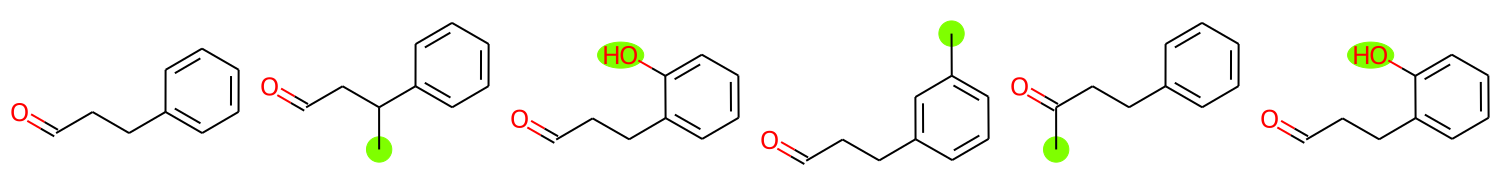

19756 CCCCCCCCCCCCS


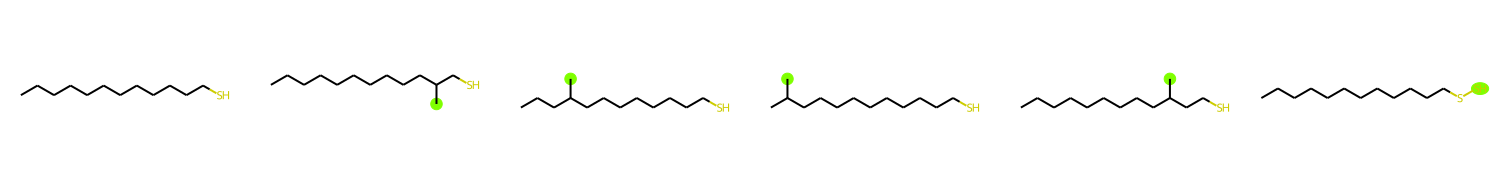

6951 OCCCCCNC(=S)S


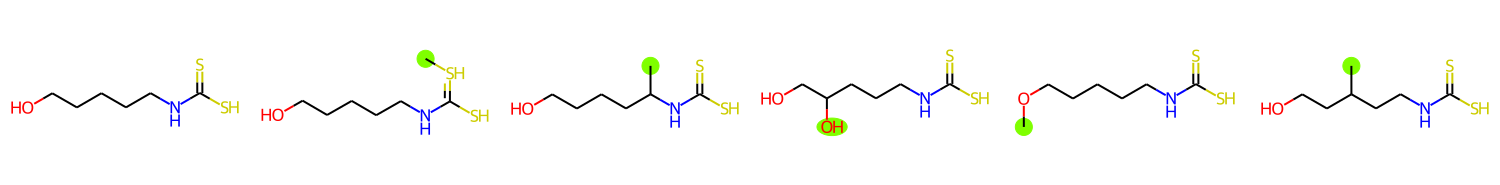

1741 CNCc1ccccc1Cl


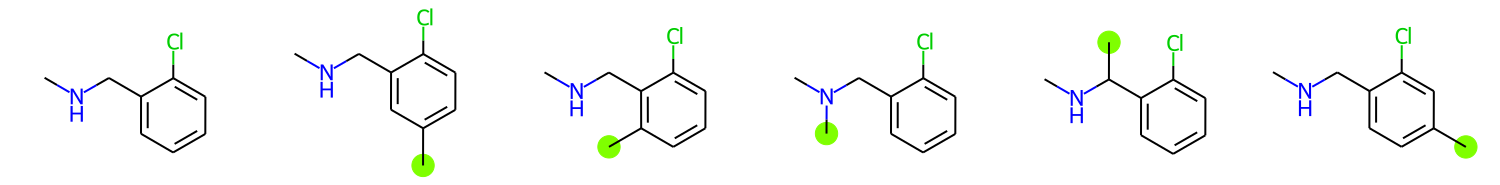

13186 CCCCNC(=O)CCCN


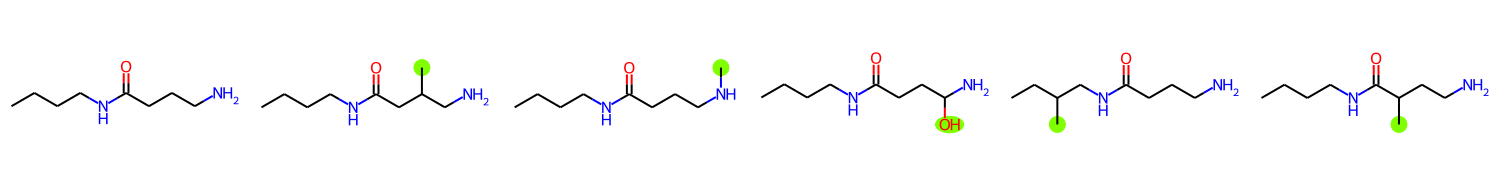

11138 CCCCCCCOC(C)=O


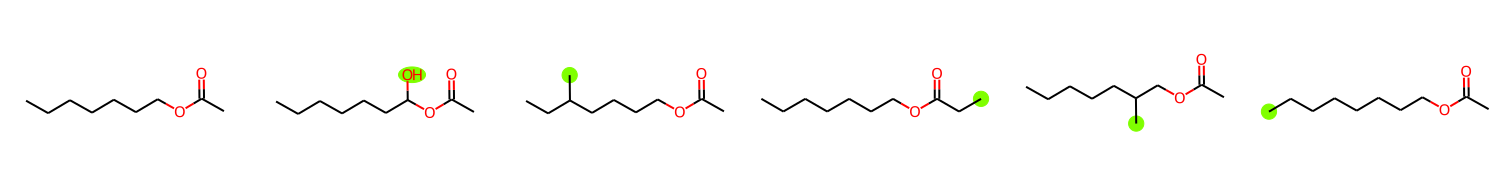

250 Oc1ccc2occc2c1


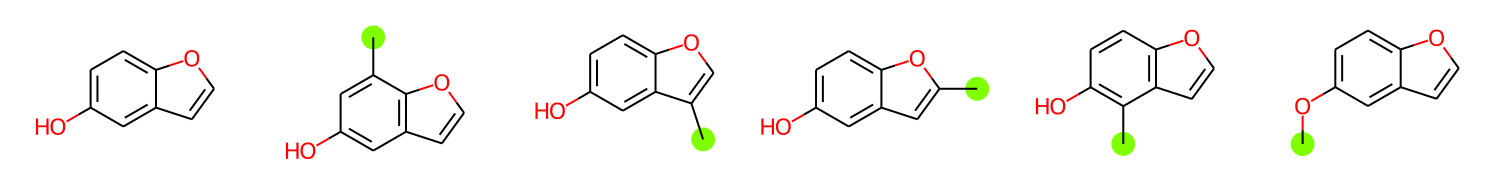

9425 CCC=CCCOC(C)=O


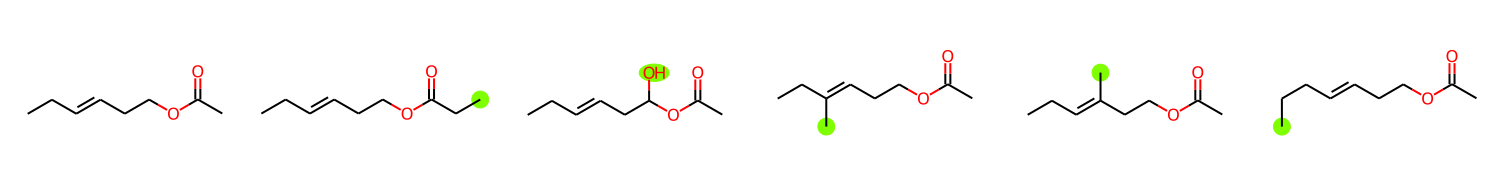

10532 CCCCCCCN(C)N=O


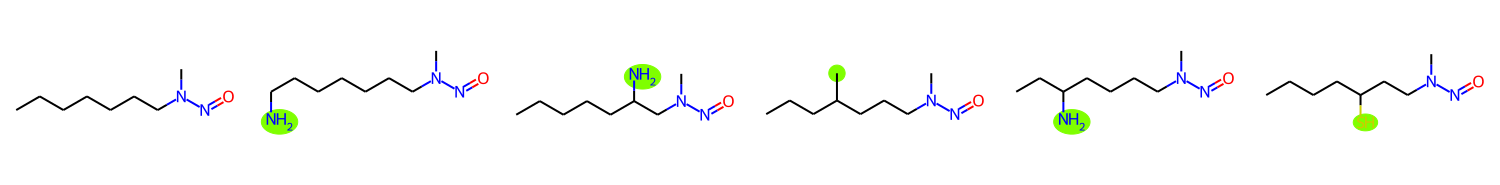

8798 CCCCCC(C)(O)CN


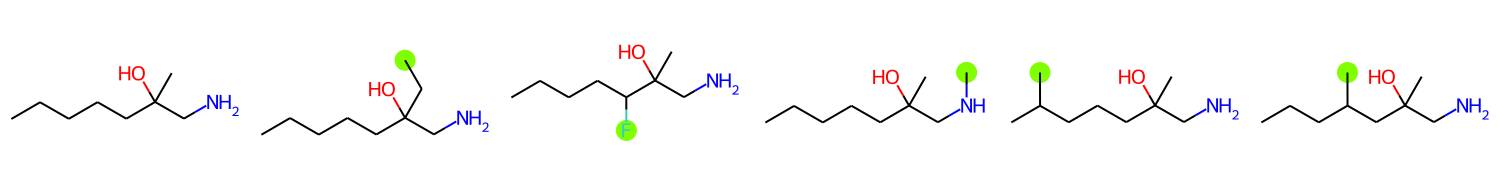

10313 O=C(O)Cc1cccnc1


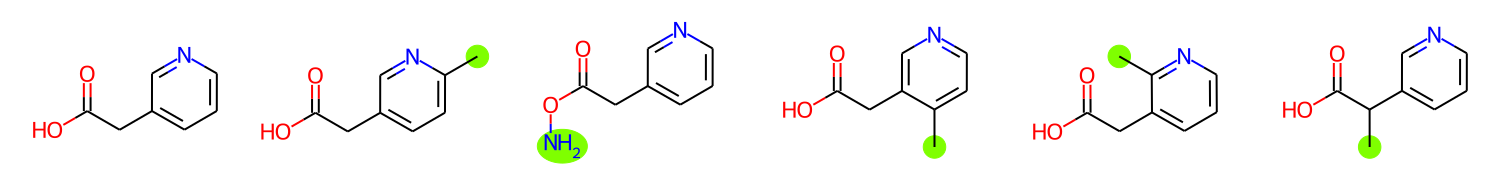

12825 CC1CCC2=NCCCN21


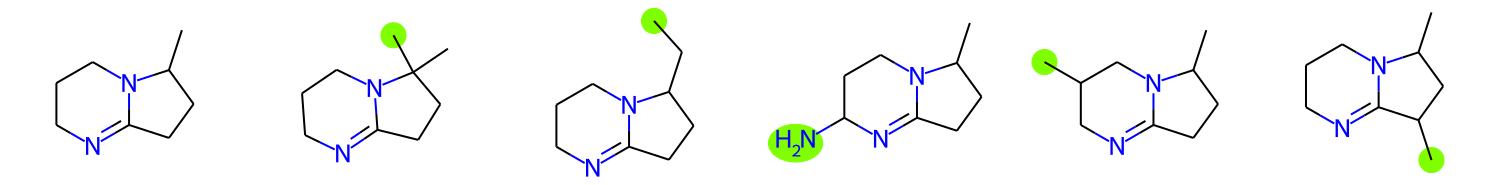

6468 CCCC(CCC)C(=O)O


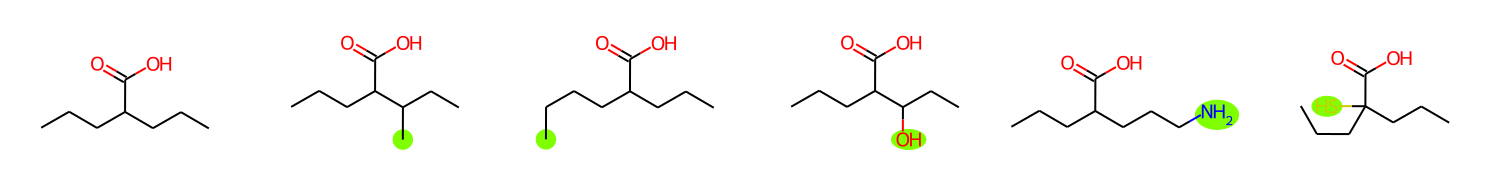

13447 ClCCN1CCCCC1CCl


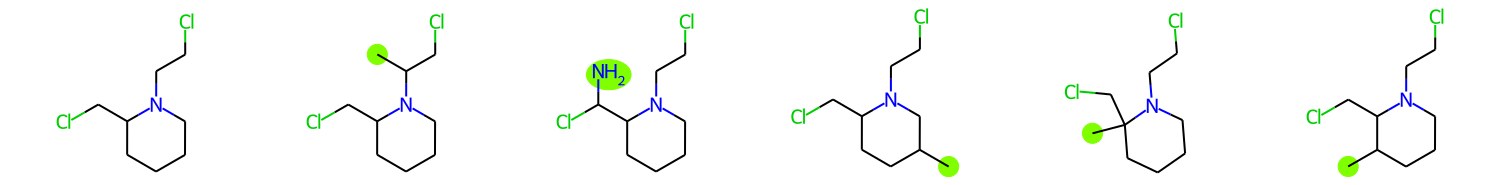

8453 CC=CC=CC(=O)NCC


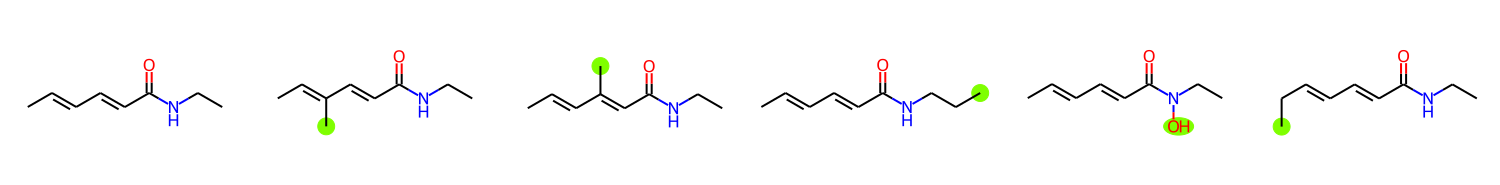

4070 Cc1nccn1CC(=O)O


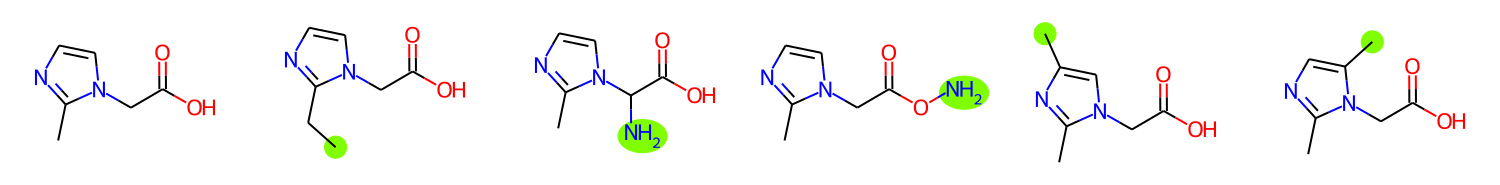

3361 Nc1ncccc1C(=O)O


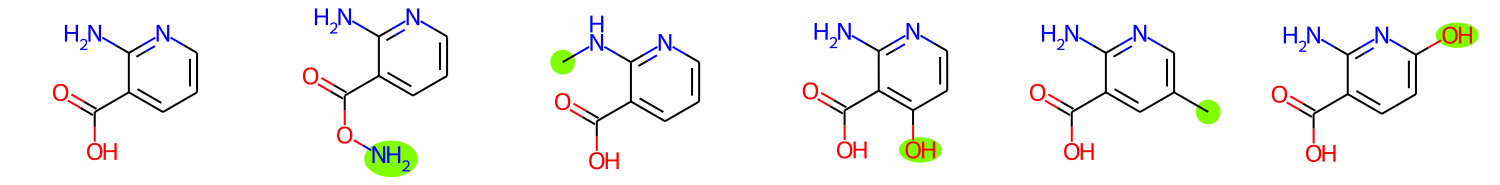

11924 NC(=O)NCc1cccs1
12297 C#Cc1ccc(OC)cc1


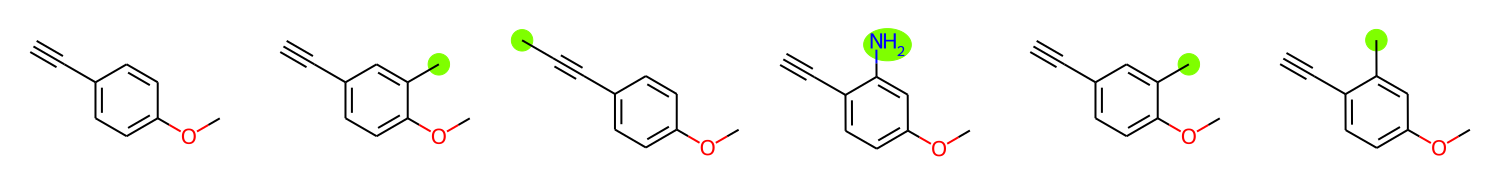

6299 CNc1ncnn2cccc12


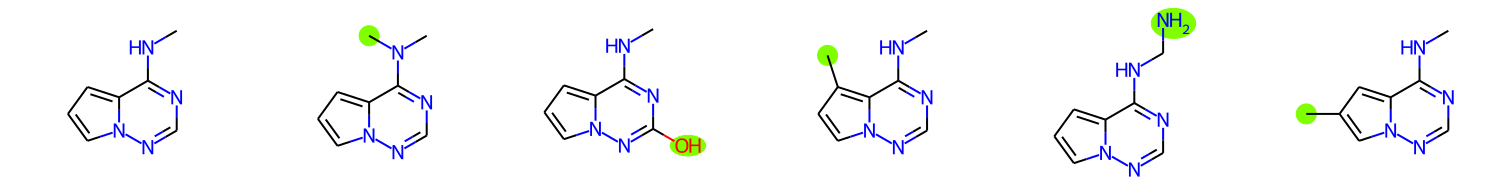

9600 Cc1ccc(SCCO)cc1


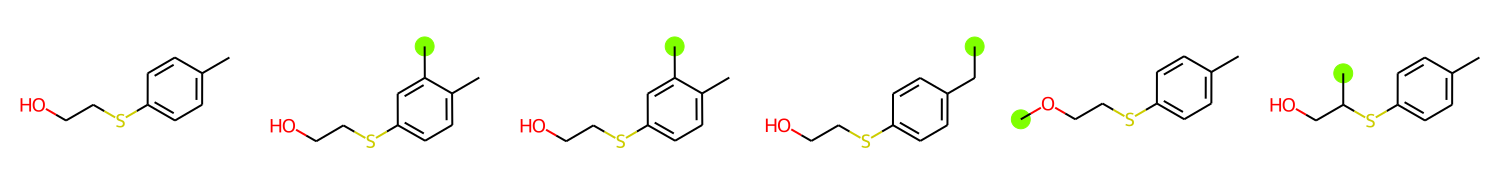

11147 CCCn1oc(C)cc1=O


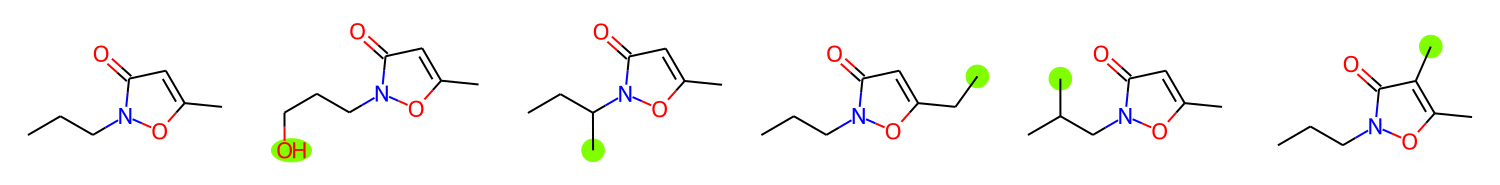

14541 CCCCCCCCOC(C)=O


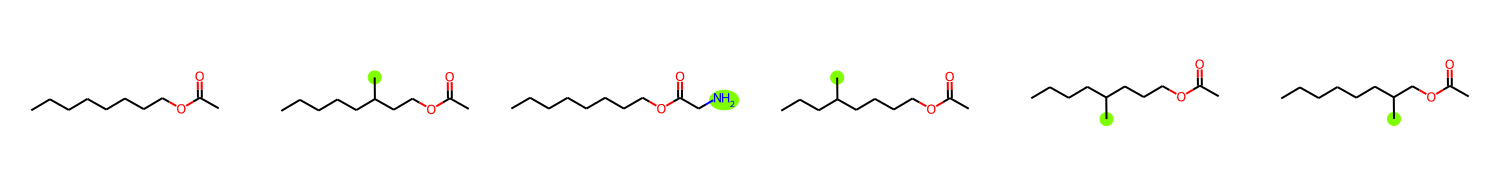

1854 O=C(Cl)c1ccccc1F


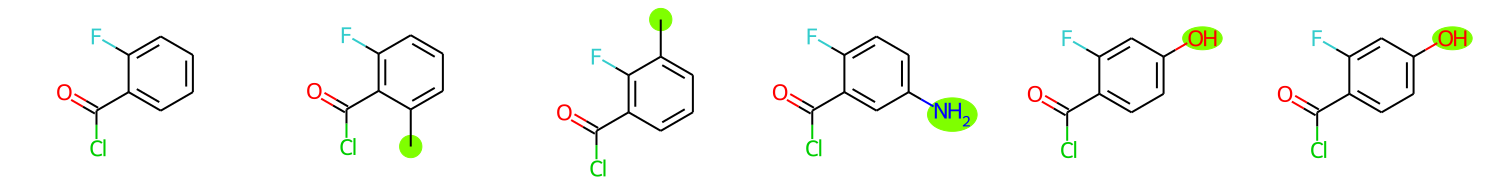

8736 CCOC(=O)c1cccnc1


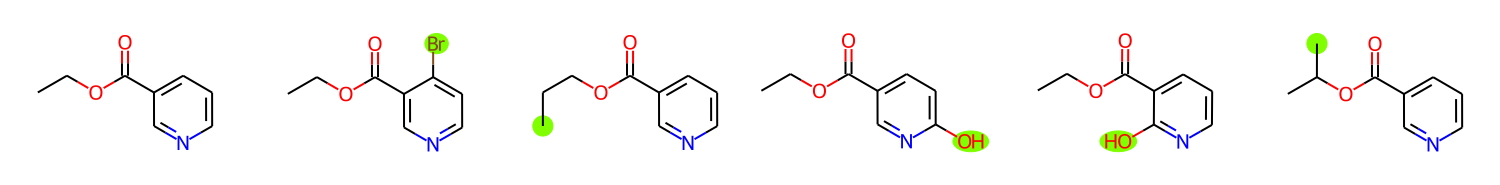

952 COC(=O)c1cssc1=S
2650 OCCOc1ccc(Cl)cc1


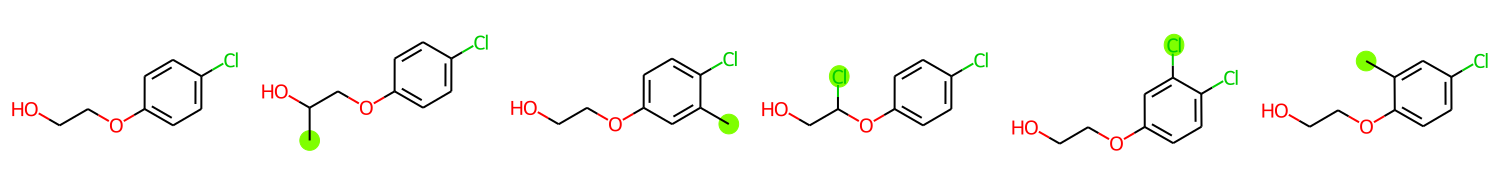

5268 CC(=O)NCCNCCNCCN


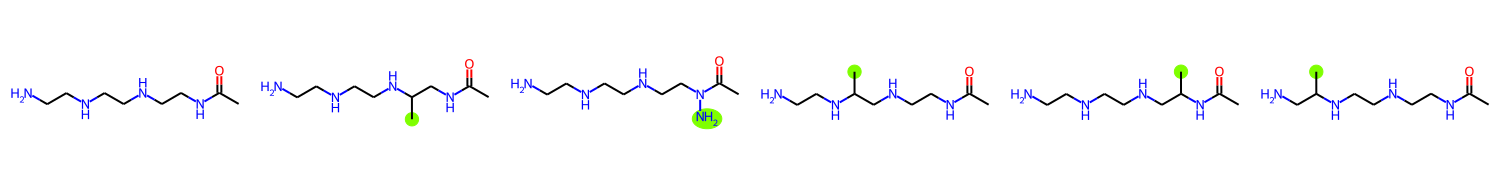

4694 CC=CC(CCC)C(=O)O


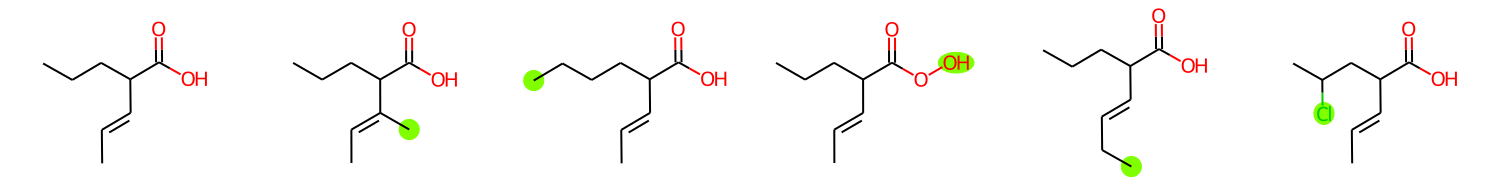

3356 CC1OOC(CO)C2OC12


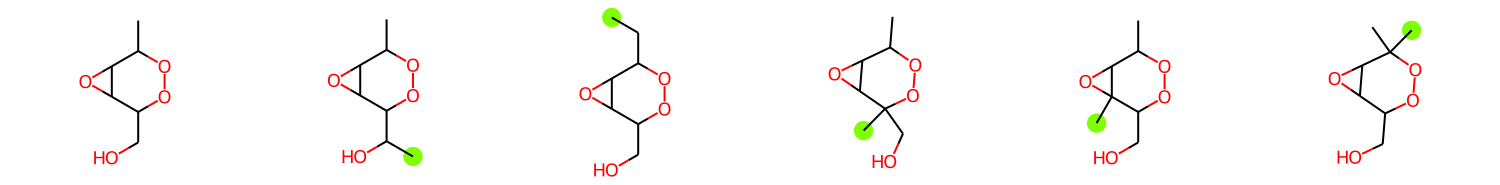

13605 OCC1CC(O)C(CO)N1


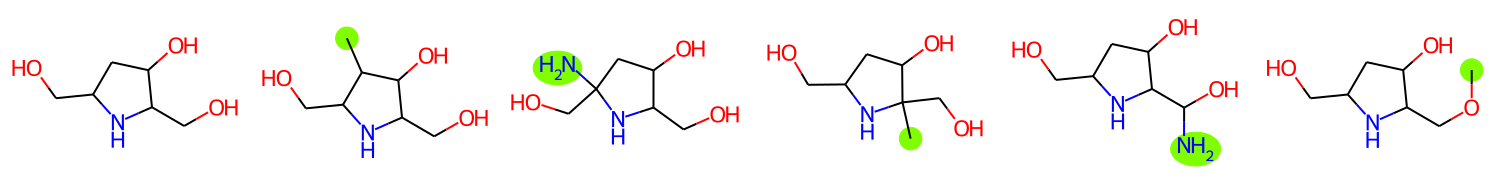

9745 C#CCNC(CS)C(=O)O


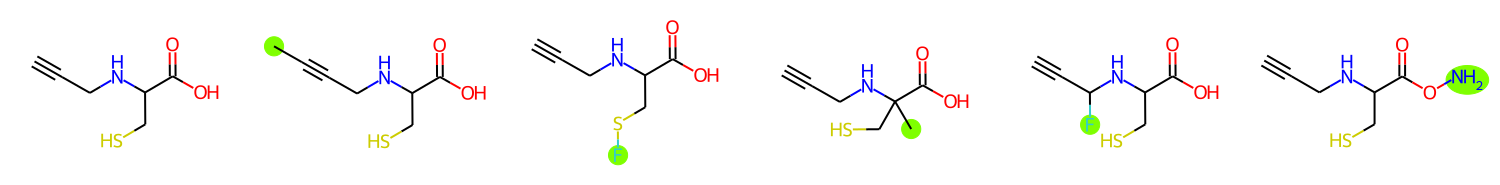

9861 CNc1nc2ccccc2n1N


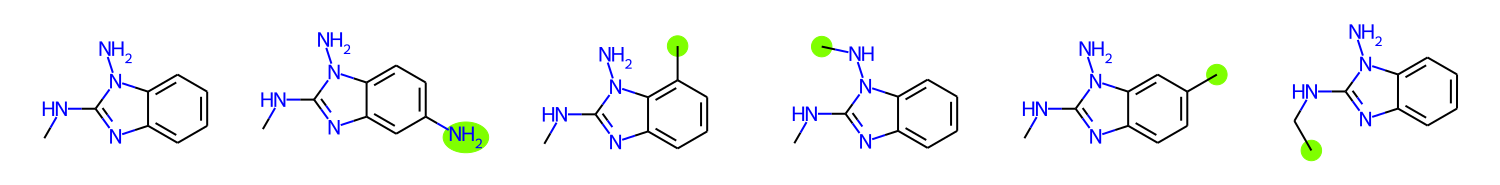

3826 CCCOCC1CC1C(=O)O


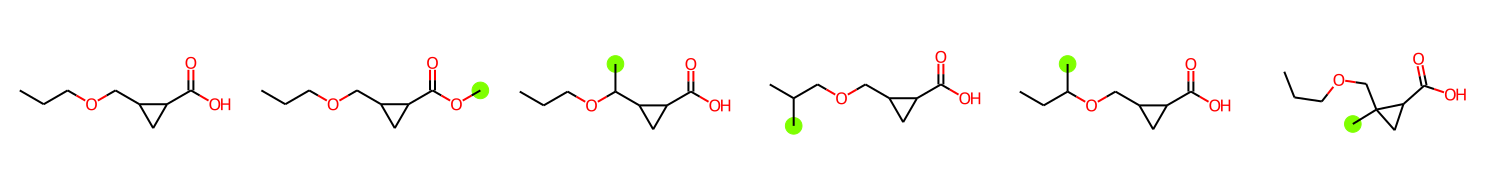

12127 CC(C)(C)NCC(O)CO


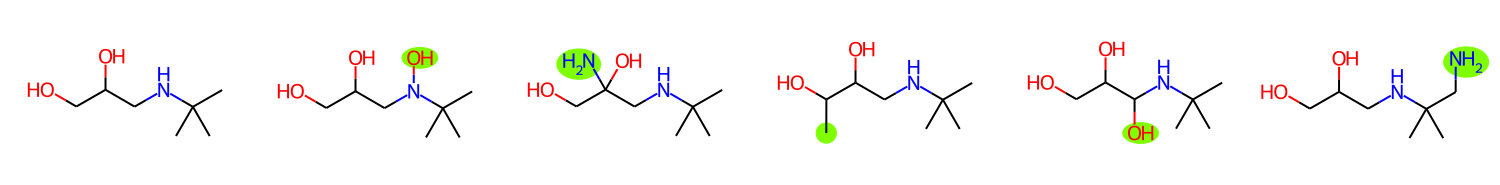

6734 O=Cc1cc(Cl)ccc1O


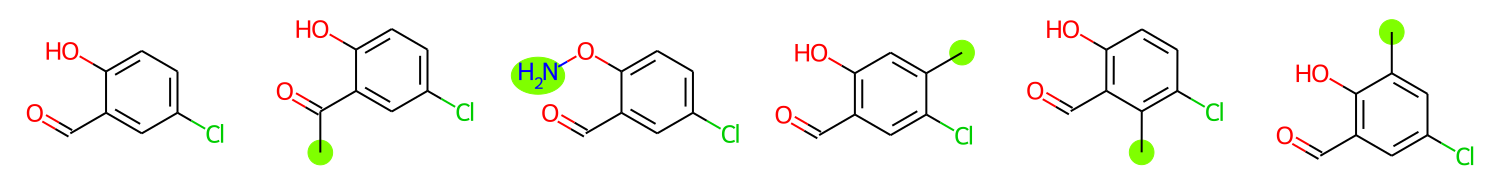

1270 NN=C(NN)NCC(=O)O


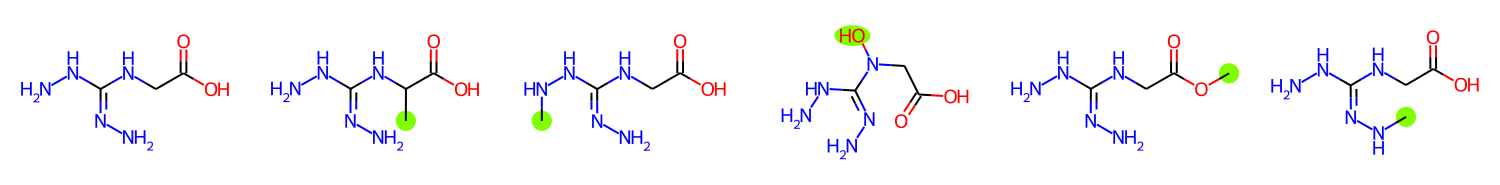

1470 CCOc1noc2c1CNCC2


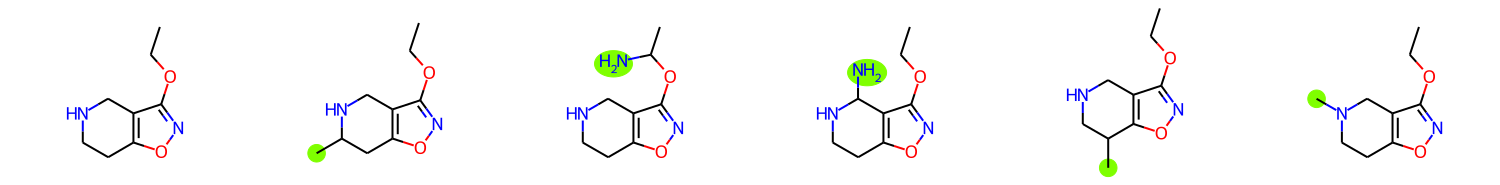

15399 C=C(C)COC1CCCCO1


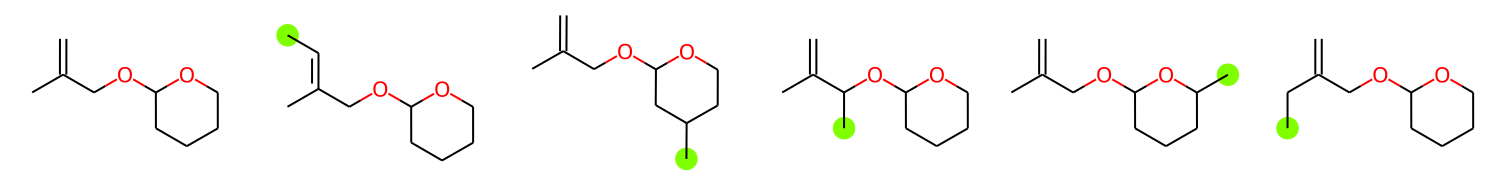

18365 N#CCC(=N)N1CCCC1


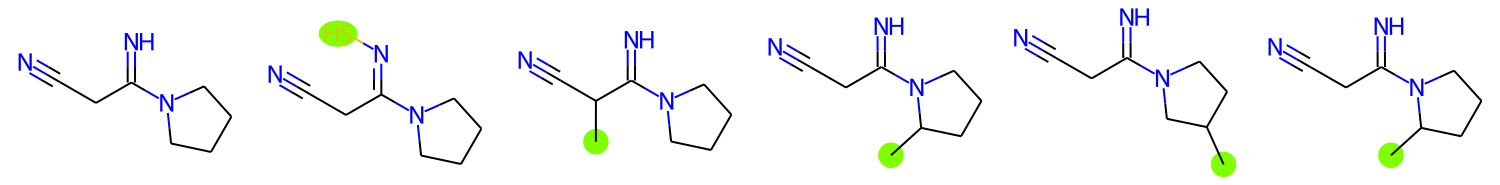

17903 CC=CC(CN)CC(=O)O


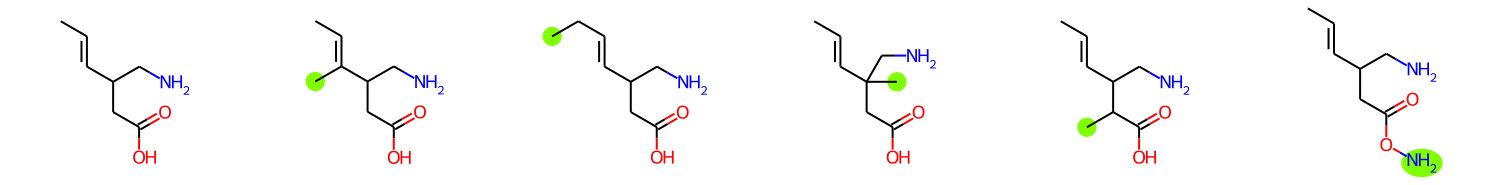

7631 COC(=O)c1ccncc1N


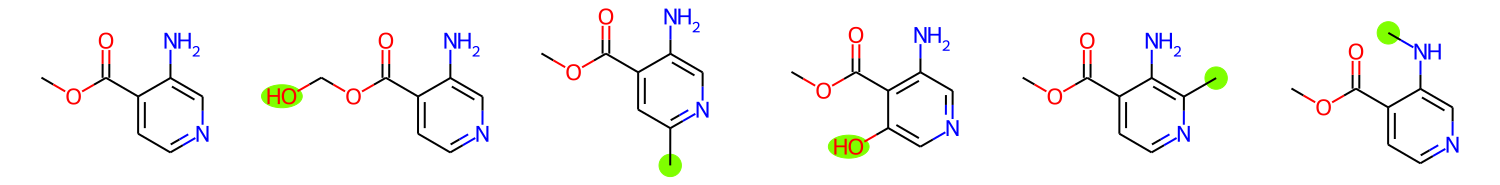

15812 Cc1cccnc1N=C(N)N


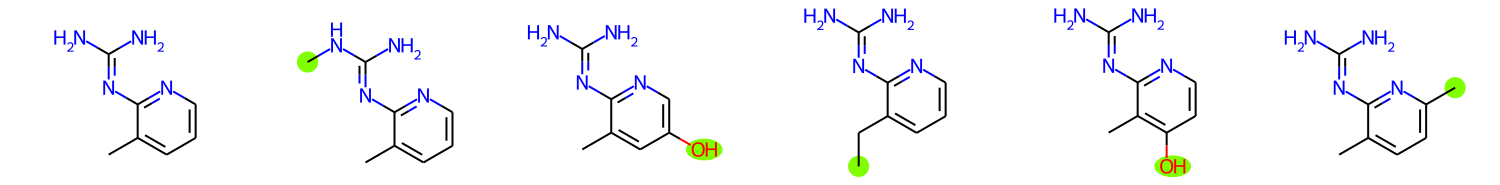

5958 CC(I)C1OCC(CO)O1


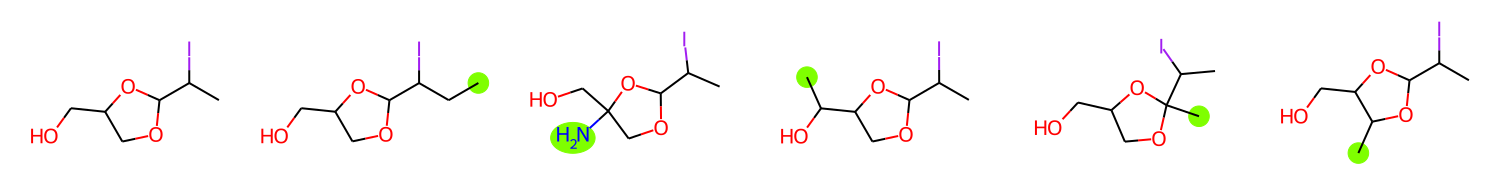

11911 CNCc1cc2cnccc2s1
5752 CCCCCc1ccc(N)cc1


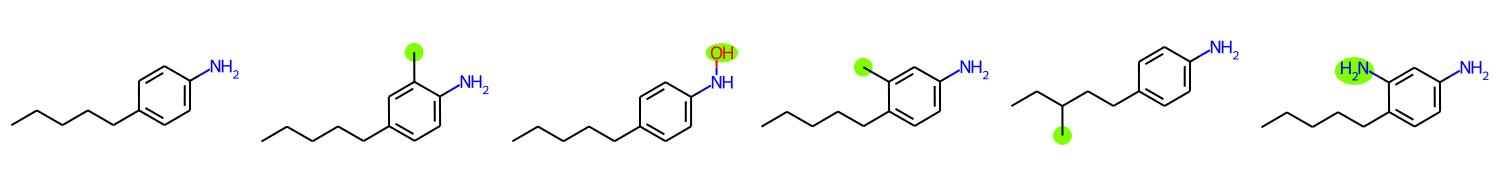

19887 CCCCCCNCc1ccccc1


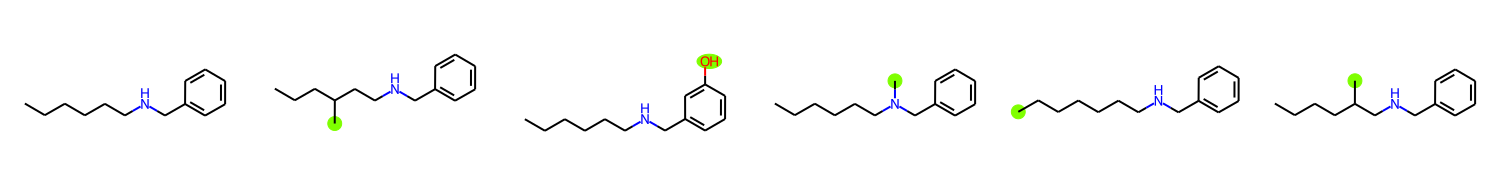

11762 OC1CC2OC2C(O)C1O


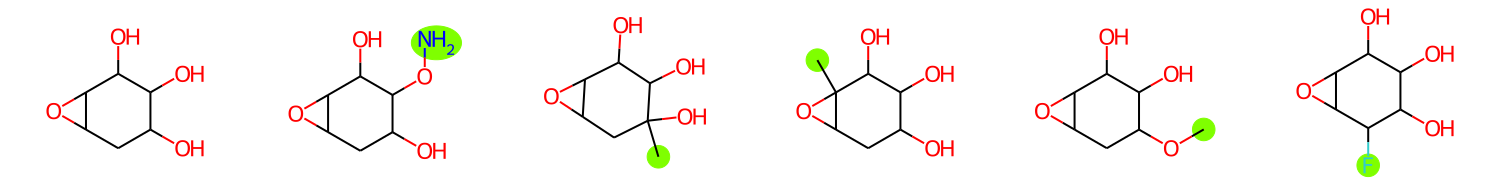

7319 CCOC(=O)Nc1csnn1
1114 CC(C)(C)N1CCC1CN


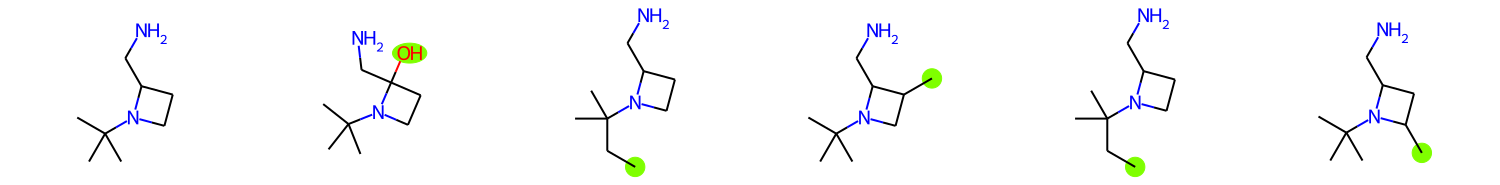

12425 CN1CCC2CC(O)CC1C2


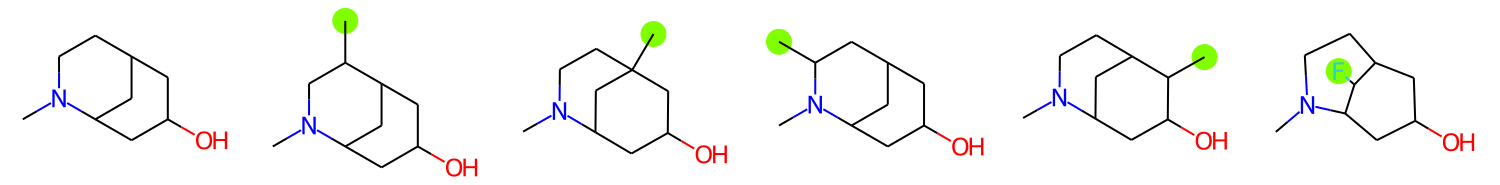

280 Cc1nccnc1N1CCCCC1


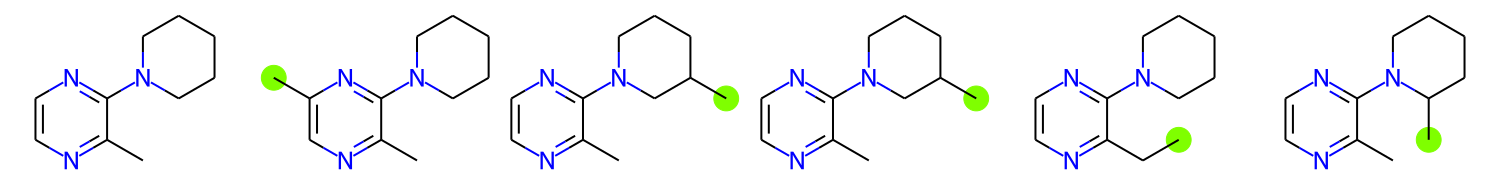

4084 Cc1nccn1-c1cccnc1


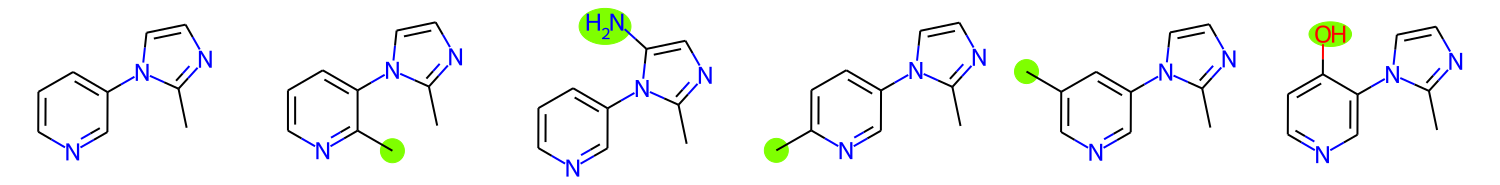

5013 C=C1CCC(O)CC1=CCO


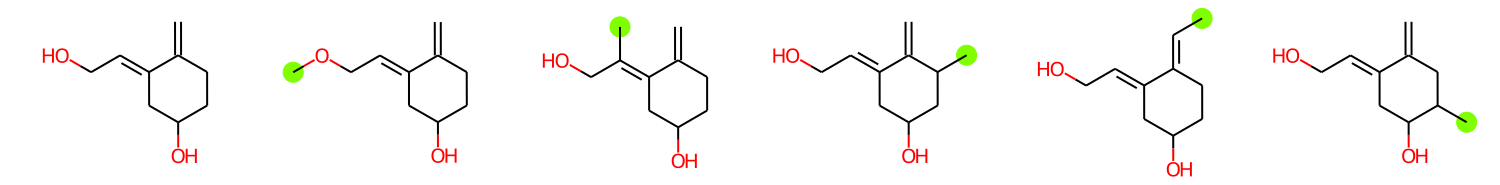

17089 NC(=O)C=Cc1cccnc1


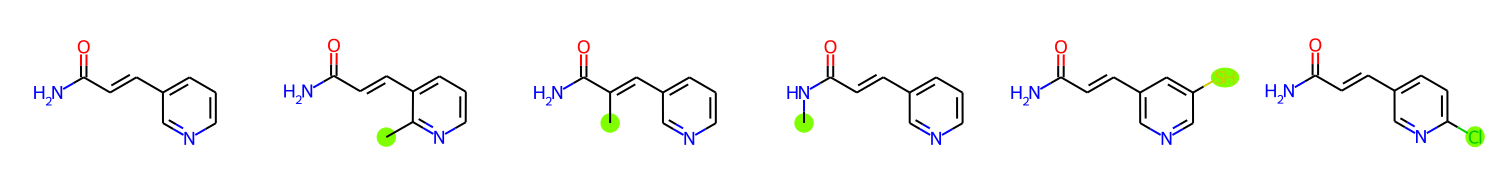

4058 CCCCCCCCNc1ncccn1


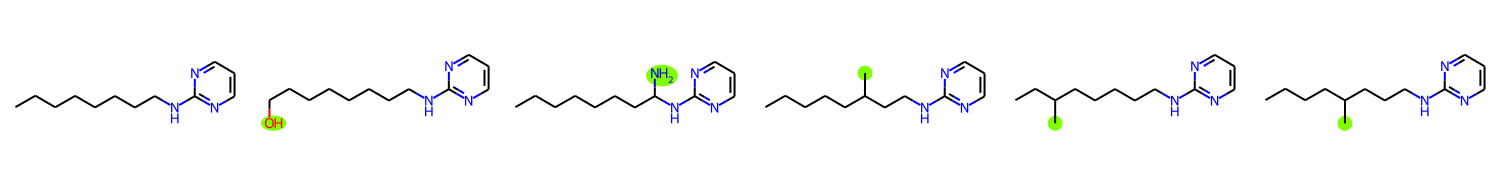

4905 Cc1cc2cccc(N)c2o1


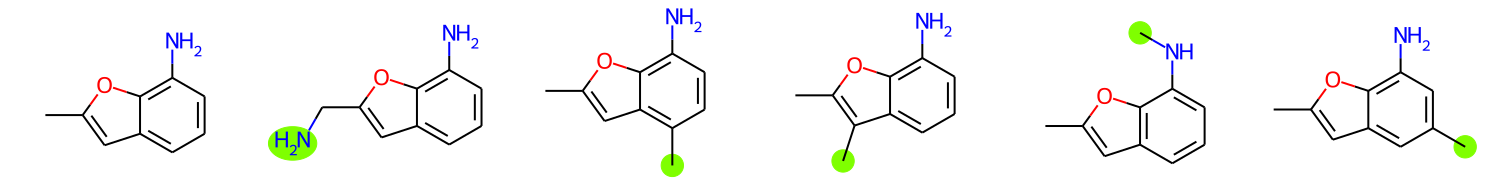

262 CC(=O)C1COC(O)C1C


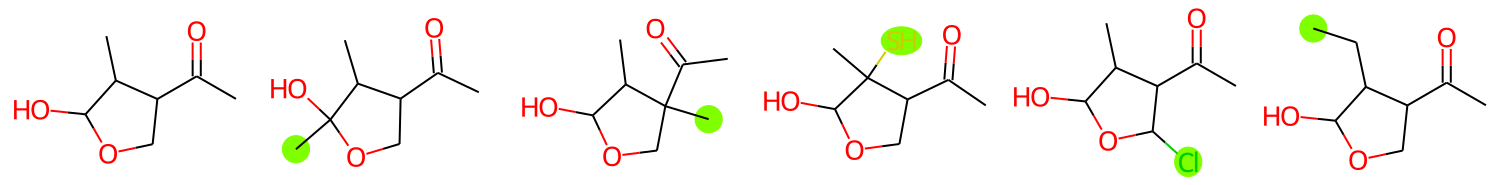

8018 CCCCCCCCCc1ccccc1


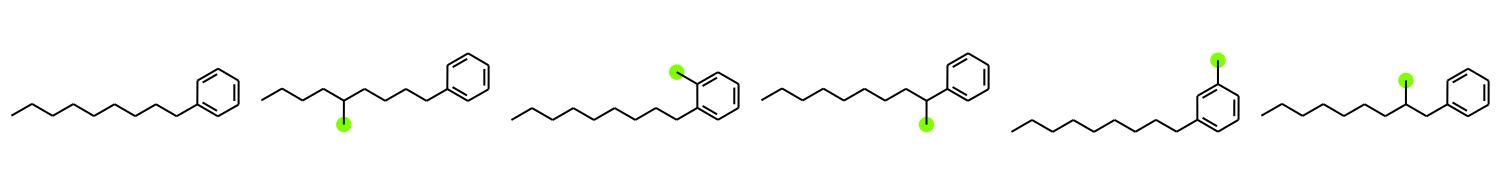

5626 C#CCN(C)C(C)CCCCC


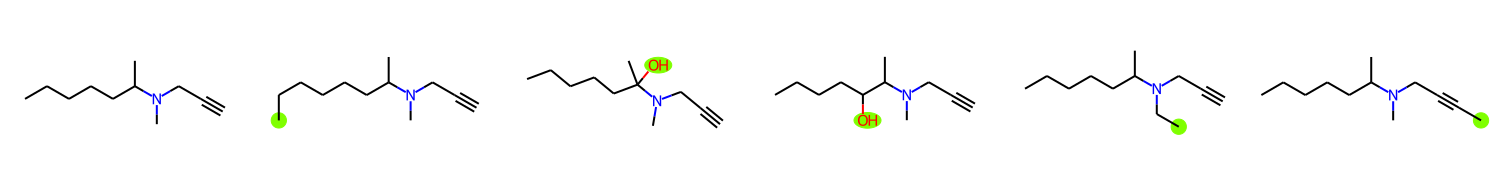

1757 CCc1ccc2ccccc2c1O


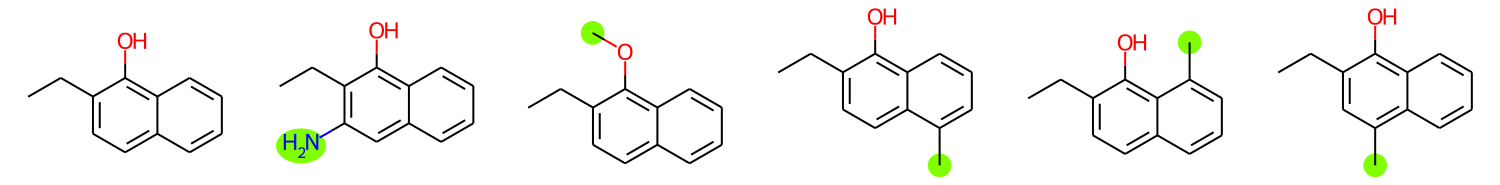

16353 O=C(O)c1cccc(S)c1


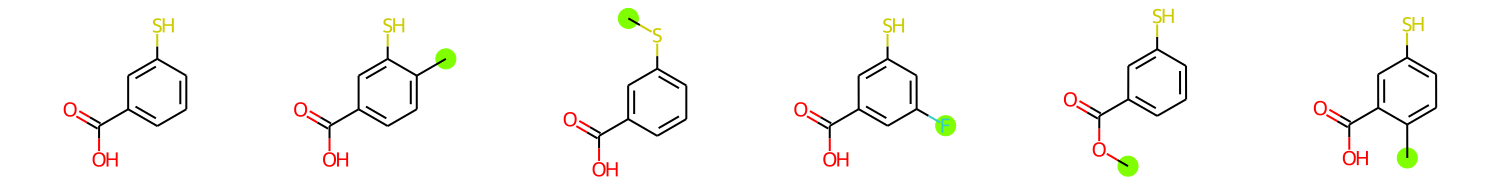

3718 CCCCCCSc1nnc(N)s1
10027 NC(CS)CSCc1ccccc1


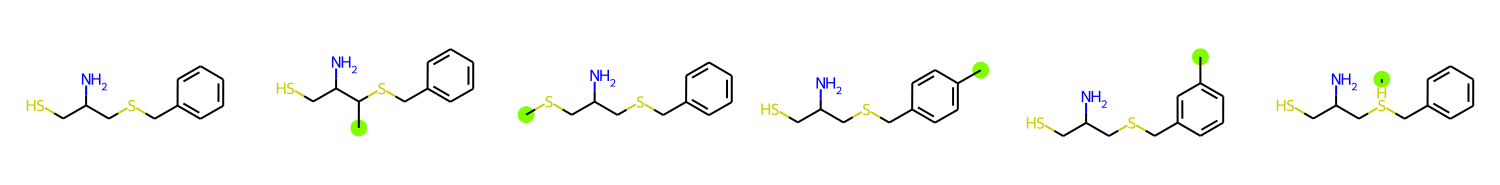

6825 NC1=NCCCc2ccccc21


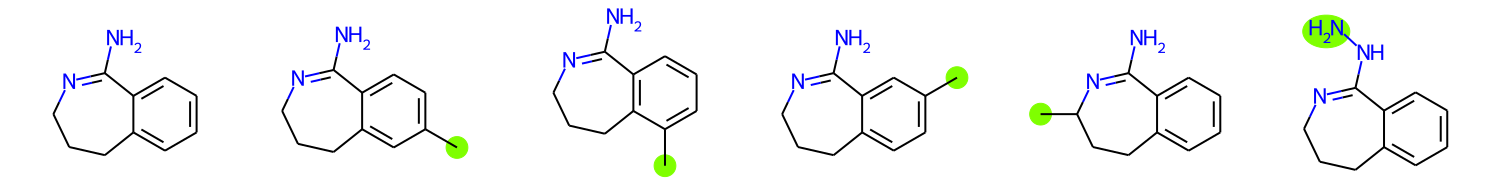

In [6]:
from rdkit.Chem import AllChem
from rdkit import Chem, Geometry
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
rdDepictor.SetPreferCoordGen(True)
# IPythonConsole.drawOptions.minFontSize=20
from matplotlib.colors import ColorConverter

def get_highlighted_atoms(anc_mol, aug_mol):
    mcs = rdFMCS.FindMCS([anc_mol,aug_mol])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    match = aug_mol.GetSubstructMatch(mcs_mol)
    highlight_atoms = []
    for atom in aug_mol.GetAtoms():
        if atom.GetIdx() not in match:
            highlight_atoms.append(atom.GetIdx())
    return highlight_atoms

from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
from io import BytesIO

# def DrawMolsZoomed(mols, subImgSize=(250, 250)):

#     fullSize = (molsPerRow * subImgSize[0], subImgSize[1])
#     full_image = Image.new('RGBA', fullSize )

#     for i, mol in enumerate(mols):
#         if i==0:
#             offset = ( column*subImgSize[0], 0 )
            
#         if mol.GetNumConformers() == 0:
#             AllChem.Compute2DCoords(mol)
#         column = ii % molsPerRow
#         row = ii // molsPerRow
#         offset = ( column*subImgSize[0], row * subImgSize[1] )
#         d2d = rdMolDraw2D.MolDraw2DCairo(subImgSize[0], subImgSize[1])
#         d2d.DrawMolecule(mol)
#         d2d.FinishDrawing()
#         sub = Image.open(BytesIO(d2d.GetDrawingText()))
#         full_image.paste(sub,box=offset)
#     return full_image


c = ColorConverter().to_rgb('chartreuse') # mediumspringgreen cyan chartreuse

for idx in df_ancs.anc_idx.values:
    
    draw = True
    smis = df[df.anc_idx==idx]
    anc_smi = smis[smis.atype=='Anc'].smiles.values[0]
    print(idx, anc_smi)
    aug_smis = smis[smis.atype=='Aug'].smiles.values
    
    anc_mol = Chem.MolFromSmiles(anc_smi)
    aug_mols = [Chem.MolFromSmiles(sm) for sm in aug_smis] 
    all_mols = [anc_mol] + aug_mols
    
    matched_coords = [x.GetSubstructMatch(anc_mol) for x in all_mols]
    
    AllChem.Compute2DCoords(anc_mol)
    coords = [anc_mol.GetConformer().GetAtomPosition(x) for x in matched_coords[0]]
    coords2D = [Geometry.Point2D(pt.x,pt.y) for pt in coords]
    
    highlights = []
    colors = []
    
    for i,mol in enumerate(all_mols):
                
        # align skeletons
        try:
            coordDict={}
            for j,coord in enumerate(coords2D):
                coordDict[matched_coords[i][j]] = coord
            AllChem.Compute2DCoords(mol,coordMap=coordDict)

            # get highlights for aug mols
            if i == 0:
                highlight = False
                atom_col = {}
            else:
                highlight = get_highlighted_atoms(anc_mol, mol)
                atom_col = {highlight[0]: c}

            colors.append(atom_col)
            highlights.append(highlight)
            
        except:
            draw = False
    if draw:
        img = Draw.MolsToGridImage(all_mols, molsPerRow=6, highlightAtomLists=highlights,
                               highlightAtomColors=colors, subImgSize=(250, 185)) # 200, 150
        display(img)
#     break